**The following visualizations all compare the values of depression in adults in the given states compared with different factors**

In [124]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [125]:
custom_colors_1 = ['#a59bfcff', '#caeb7aff', '#6ec5faff', '#f06bb6ff', '#ff9c69ff']

In [126]:
# **The values in the following tables represent the percentage of adults in the state that reported 
# to have been diagnosed with depression or a depressive disorder by a health professional**
# Data Source - CDC, 2023 Behavioral Risk Factor Surveillance System Survey

# DEPRESSION ACROSS US - Distribution of depression levels across states graph

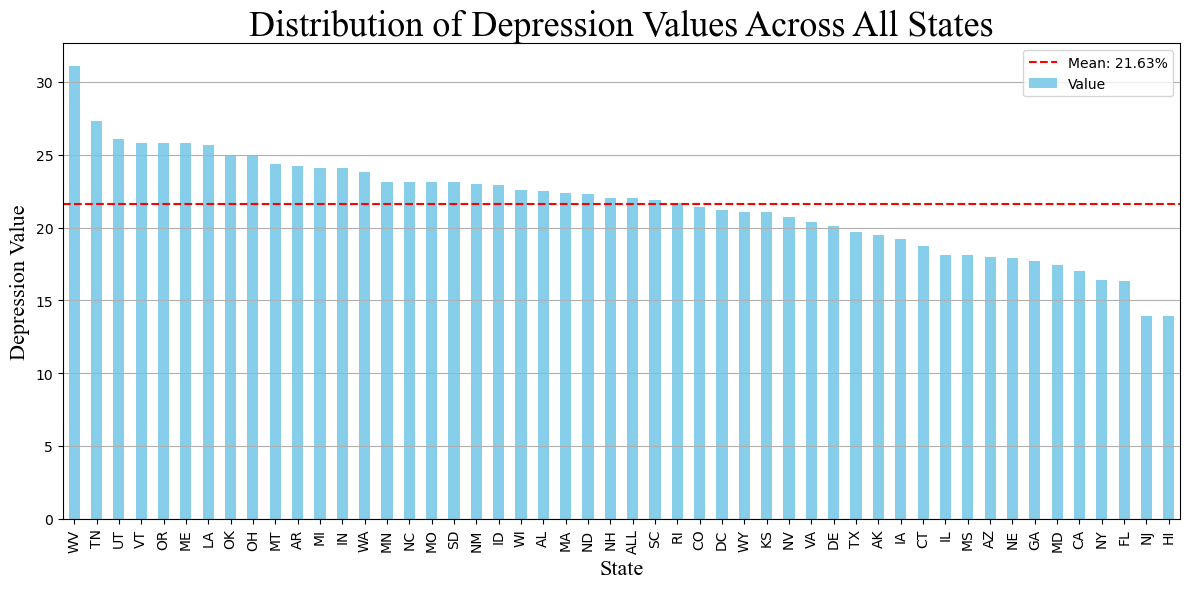

In [186]:
# read in csv
df15 = pd.read_csv("Depression_ValueDistribution_AllStates.csv")

# clean data 
df15['Value'] = pd.to_numeric(df15['Value'])
df_clean15 = df15.dropna(subset = ['Value'])
df_clean15 = df_clean15.sort_values(by = 'Value', ascending = False)

# make distribution plot
df_clean15 = df_clean15.set_index('State') # makes the state the x - axis
ax = df_clean15['Value'].plot(kind='bar',figsize=(12,6), color = 'skyblue')

ax.set_title("Distribution of Depression Values Across All States", fontsize = 26,fontname='Times New Roman')                 
ax.set_xlabel("State", fontsize=16,fontname='Times New Roman')
ax.set_ylabel("Depression Value",fontsize=16,fontname='Times New Roman')
mean_val = df_clean15['Value'].mean()
ax.axhline(mean_val, color='red', linestyle='--', label=f"Mean: {mean_val:.2f}%")
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False,
          prop={'family': 'Times New Roman'},
          title_fontproperties={'family':'Times New Roman'})

In [128]:
# Get stats from the distribution
min_val = df_clean15['Value'].min()
max_val = df_clean15['Value'].max()
print("States have depression scores ranging from "+str(min_val)+".% to "+str(max_val)+".%")
std_val = df_clean15['Value'].std()
#print("Stand Dev: " + str(std_val))
print("On average, the depression value percentage for a state differs from the average depression" +
      "value, which is " + str(int(mean_val))+ "%," + " by 3.5%")
iqr_val = df_clean15['Value'].quantile(0.75) - df_clean15['Value'].quantile(0.25)

States have depression scores ranging from 13.9.% to 31.1.%
On average, the depression value percentage for a state differs from the average depressionvalue, which is 21%, by 3.5%


In [129]:
# Save Figure
DepressionDistributionFig = ax.get_figure()
DepressionDistributionFig.savefig("figures/DepressionDistributionFig.png", bbox_inches = 'tight',transparent=True,dpi=300)

### DEPRESSION BY INCOME LEVEL (ACROSS STATES) 
- Among adults of varing income levels, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
- shows the prevalence of depression within each income bracket

In [130]:
# read in csv
df1 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])

# make filter for the income labels in the Measure column
incomes = ['Depression - Less Than $25,000','Depression - $25,000-$49,999','Depression - $50,000-$74,999','Depression - $75,000 or More']

# only get entries w/ income in measure
df_clean = df1[df1['Measure'].isin(incomes)] 

# for the visualization later, make a new column w/ desired names for each measure/bin
newNamelyst = [] # make empty list to store new row/entry names when iterating thru measures column

for row in df_clean['Measure']:
    if (row == 'Depression - Less Than $25,000'): # if row == old/original name
          newNamelyst.append('>25k$') # add new name to list for the new column
    elif(row == 'Depression - $25,000-$49,999'):
          newNamelyst.append('25-50k$')
    elif(row == 'Depression - $50,000-$74,999'):
          newNamelyst.append('50-75k$')
    elif(row == 'Depression - $75,000 or More'):
          newNamelyst.append('75k$<')
df_clean['Income Levels'] = newNamelyst # adds the new list of desired labels as new column
df_clean.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/687609235.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Income Levels'] = newNamelyst # adds the new list of desired labels as new column


,Measure,State,Value,Income Levels
85,"Depression - $25,000-$49,999",HI,16.3,25-50k$
86,"Depression - $25,000-$49,999",IA,22.6,25-50k$
87,"Depression - $25,000-$49,999",MI,25.4,25-50k$
88,"Depression - $25,000-$49,999",ND,27.9,25-50k$
89,"Depression - $25,000-$49,999",WV,35.6,25-50k$


In [131]:
# table where states are lines, x axis is income level, and y axis is depression value/percentage
pivot_df = df_clean.pivot(index = 'State', columns=['Income Levels'] , values = 'Value')
# index = state --> make the rows of the table the 'State' column
# columns = measure --> make the column names of the table the income labels 
# values - Value --> make the cell value in the table the depression percentages
    # for each state based on income level 
pivot_df

Income Levels,25-50k$,50-75k$,75k$<,>25k$
State,,,,
HI,16.3,11.8,11.8,25.7
IA,22.6,16.5,14.1,31.3
MI,25.4,21.7,18.5,36.5
ND,27.9,19.4,16.2,39.9
WV,35.6,27.3,22.4,42.9


In [132]:
# Plot the pivot table as a line chart
# - choose order that bins will appear in on the chart
new_column_order = ['>25k$', '25-50k$', '50-75k$', '75k$<'] # make new order
pivot_table_reordered = pivot_df.reindex(columns=new_column_order) # Reorder the columns
# reindex - changes order of columns
# transpose the pivot table /switch the axes before plotting graph
transposed_pivot = pivot_table_reordered.T # switches axis 
transposed_pivot 

State,HI,IA,MI,ND,WV
Income Levels,,,,,
>25k$,25.7,31.3,36.5,39.9,42.9
25-50k$,16.3,22.6,25.4,27.9,35.6
50-75k$,11.8,16.5,21.7,19.4,27.3
75k$<,11.8,14.1,18.5,16.2,22.4


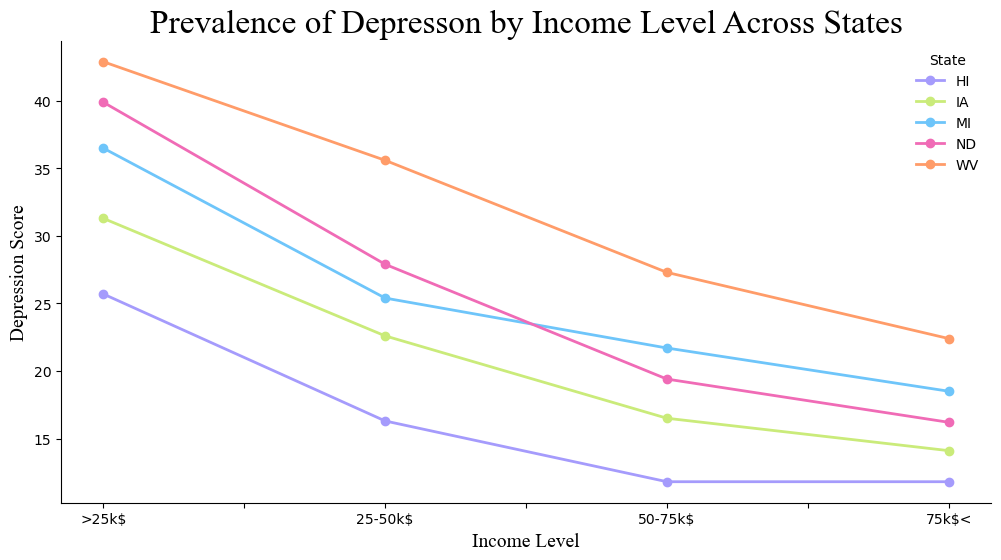

In [139]:
# - use .plot() to make line plot w/ matplotlib
ax = transposed_pivot.plot(kind='line', figsize=(12, 6), marker='o', color=custom_colors_1,linewidth=2)
    # each column in transposed_pivot dataframe will be a separate line on the plot (states are the lines)
    # mark the data points 
    # assign the plot to "ax" to be able to customize 
ax.set_title("Prevalence of Depresson by Income Level Across States",fontsize=24, fontname="Times New Roman")
ax.set_xlabel("Income Level",fontsize=14,fontname="Times New Roman")
ax.set_ylabel("Depression Score",fontsize=14,fontname="Times New Roman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)

In [140]:
# Save Figure
DepressionPrevalenceByIncomeFig = ax.get_figure()
DepressionPrevalenceByIncomeFig.savefig("figures/DepressionByIncome_LinePlot.png", bbox_inches = 'tight',transparent=True,dpi=300)

# DEPRESSION BY AGES (ACROSS STATES)
- Among adults of varying ages, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
- shows the prevalence of depression within each age group

In [141]:
df2 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value']) # read in csv
ages = ['Depression - Ages 18-44','Depression - Ages 45-64','Depression - Age 65+']	# make filter for the income labels in the Measure column
df_clean2 = df2[df2['Measure'].isin(ages)] # only get entries w/ age in measure

newNamelyst2 = [] # make empty list to store new row/entry names when iterating thru measures column
for row in df_clean2['Measure']:
    if (row == 'Depression - Ages 18-44'): # if row == old/original name
          newNamelyst2.append('18-44 yrs') # add new name to list for the new column
    elif(row == 'Depression - Ages 45-64'):
          newNamelyst2.append('45-65 yrs')
    elif(row == 'Depression - Age 65+'):
          newNamelyst2.append('> 65 yrs')
df_clean2['Age Groups'] = newNamelyst2 # adds the new list of desired labels as new column
df_clean2.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/3958062638.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean2['Age Groups'] = newNamelyst2 # adds the new list of desired labels as new column


,Measure,State,Value,Age Groups
15,Depression - Ages 18-44,HI,16.2,18-44 yrs
16,Depression - Ages 18-44,IA,24.0,18-44 yrs
17,Depression - Ages 18-44,MI,29.5,18-44 yrs
18,Depression - Ages 18-44,ND,28.5,18-44 yrs
19,Depression - Ages 18-44,WV,36.5,18-44 yrs


In [142]:
pivot_df2 = df_clean2.pivot(index = 'State', columns=['Age Groups'] , values = 'Value') 
pivot_df2

Age Groups,18-44 yrs,45-65 yrs,> 65 yrs
State,,,
HI,16.2,14.0,10.0
IA,24.0,17.9,12.3
MI,29.5,22.7,16.8
ND,28.5,18.5,13.7
WV,36.5,32.8,21.5


In [143]:
transposed_pivot2 = pivot_df2.T # switches axis 
transposed_pivot2

State,HI,IA,MI,ND,WV
Age Groups,,,,,
18-44 yrs,16.2,24.0,29.5,28.5,36.5
45-65 yrs,14.0,17.9,22.7,18.5,32.8
> 65 yrs,10.0,12.3,16.8,13.7,21.5


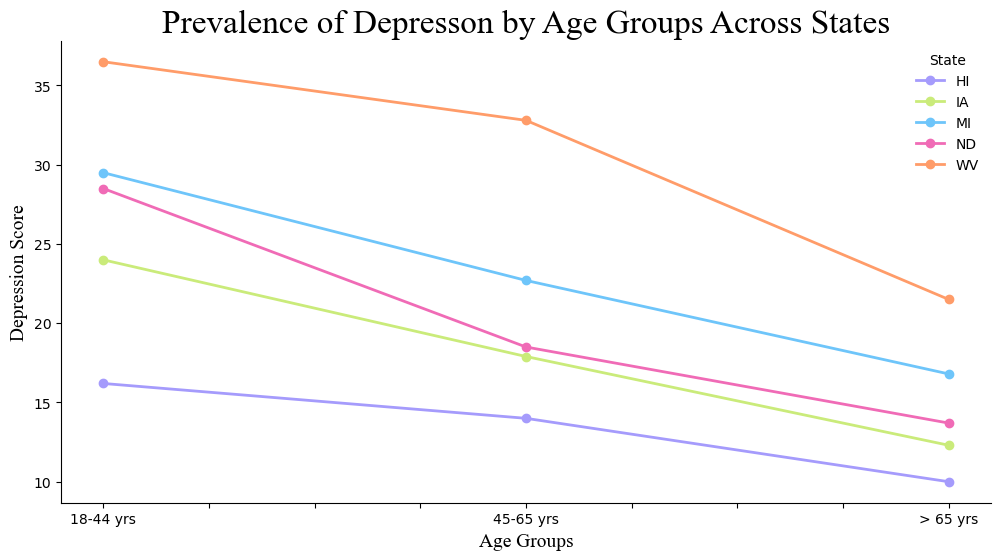

In [144]:
ax = transposed_pivot2.plot(kind='line', figsize=(12, 6), marker='o',color=custom_colors_1,linewidth=2)
ax.set_title("Prevalence of Depresson by Age Groups Across States",fontsize=24, fontname="Times New Roman")
ax.set_xlabel("Age Groups",fontsize=14,fontname="Times New Roman")
ax.set_ylabel("Depression Score",fontsize=14,fontname="Times New Roman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)

In [148]:
# Save Figure
DepressionPrevalenceByAgeGroupFig = ax.get_figure()
DepressionPrevalenceByAgeGroupFig.savefig("figures/DepressionByAgeGroup_LinePlot.png", bbox_inches = 'tight',transparent=True,dpi=300)

# DEPRESSION BY SEX (ACROSS STATES)
- Among males and females, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder 
- shows the prevalence of depression in males vs females

In [149]:
df3 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value']) # read in csv
sex = ['Depression - Female','Depression - Male'] # filter 
df_clean3 = df3[df3['Measure'].isin(sex)] # # only get entries w/ age group in measure
newNamelyst3 = [] # make empty list to store new row/entry names when iterating thru measures column
for row in df_clean3['Measure']:
    if (row == 'Depression - Female'): # if row == old/original name
          newNamelyst3.append('Female') # add new name to list for the new column
    elif(row == 'Depression - Male'):
          newNamelyst3.append('Male')
df_clean3['Sex'] = newNamelyst3 # adds the new list of desired labels as new column
df_clean3.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/1164017242.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean3['Sex'] = newNamelyst3 # adds the new list of desired labels as new column


,Measure,State,Value,Sex
5,Depression - Female,HI,17.4,Female
6,Depression - Female,IA,25.8,Female
7,Depression - Female,MI,31.2,Female
8,Depression - Female,ND,30.5,Female
9,Depression - Female,WV,39.1,Female


In [150]:
pivot_df3 = df_clean3.pivot(index = 'State', columns=['Sex'] , values = 'Value')
pivot_df3

Sex,Female,Male
State,,
HI,17.4,10.3
IA,25.8,12.4
MI,31.2,16.7
ND,30.5,14.5
WV,39.1,22.9


In [151]:
new_column_order3 = ['Female','Male'] # make new order
pivot_table_reordered3 = pivot_df3.reindex(columns=new_column_order3) # Reorder the columns
transposed_pivot3 = pivot_table_reordered3.T # switches axis 
transposed_pivot3

State,HI,IA,MI,ND,WV
Sex,,,,,
Female,17.4,25.8,31.2,30.5,39.1
Male,10.3,12.4,16.7,14.5,22.9


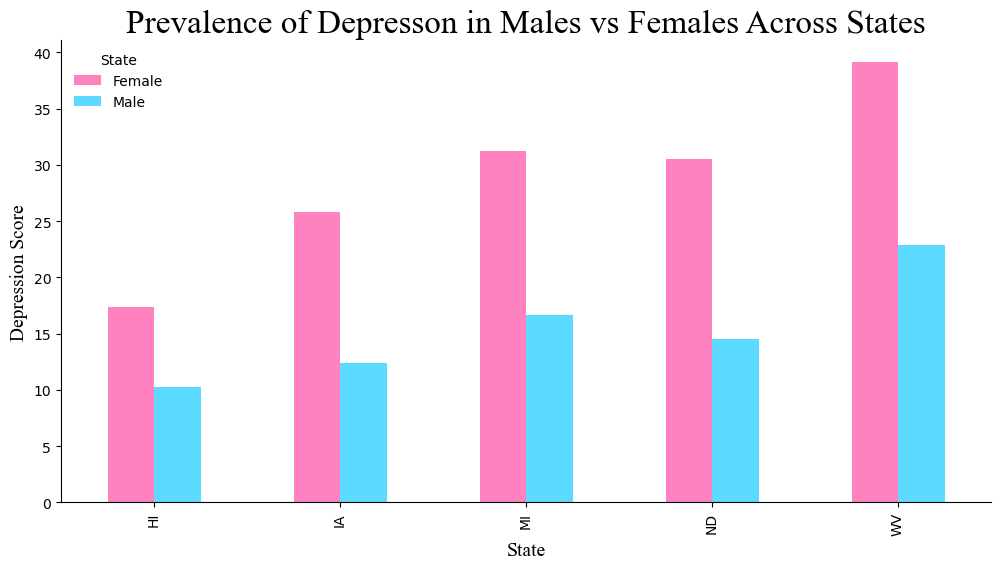

In [152]:
# Grouped Bar Plot
custom_color_3 = ['#fd82bfff','#5cdaffff']
ax = pivot_table_reordered3.plot(kind='bar', figsize=(12,6), color=custom_color_3)
ax.set_title("Prevalence of Depresson in Males vs Females Across States", fontsize=24,fontname="Times New Roman")
#ax.set_xlabel("States",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=14,fontname="Times New Roman")
ax.set_xlabel("State",fontsize=14,fontname="Times New Roman")
custom_color_3 = ['#fd82bfff','#5cdaffff']
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)

In [154]:
# Save Figure
DepressionPrevalenceBySexFig = ax.get_figure()
DepressionPrevalenceBySexFig.savefig("figures/DepressionBySex_BarGraph.png", bbox_inches = 'tight',transparent=True,dpi=300)

# DEPRESSION IN METRO VS NON METRO AREAS (ACROSS STATES)
- Among adults living in metro and non metro areas, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
shows the prevalence of depression within each income bracket
- Shows the prevelance of depression in metro vs non metro areas 

In [156]:
df4 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value']) # read in csv
is_metro = ['Depression - Metro', 'Depression - Non-Metro'] # Filter
df_clean4 = df4[df4['Measure'].isin(is_metro)] # only get entries w/ metro vs non metro in measure
newNamelyst4 = [] # make empty list to store new row/entry names when iterating thru measures column
for row in df_clean4['Measure']:
    if (row == 'Depression - Metro'): # if row == old/original name
          newNamelyst4.append('Metro') # add new name to list for the new column
    elif(row == 'Depression - Non-Metro'):
          newNamelyst4.append('Non-Metro')
df_clean4['Metro vs Non-Metro'] = newNamelyst4 # adds the new list of desired labels as new column++
df_clean4.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/640871418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean4['Metro vs Non-Metro'] = newNamelyst4 # adds the new list of desired labels as new column++


,Measure,State,Value,Metro vs Non-Metro
140,Depression - Metro,HI,13.1,Metro
141,Depression - Metro,IA,19.9,Metro
142,Depression - Metro,MI,23.6,Metro
143,Depression - Metro,ND,23.6,Metro
144,Depression - Metro,WV,30.2,Metro


In [157]:
pivot_df4 = df_clean4.pivot(index = 'State', columns=['Metro vs Non-Metro'] , values = 'Value') 
pivot_df4

Metro vs Non-Metro,Metro,Non-Metro
State,,
HI,13.1,17.2
IA,19.9,18.3
MI,23.6,26.1
ND,23.6,20.9
WV,30.2,32.7


In [158]:
new_column_order4 = ['Metro','Non-Metro'] # make new order
pivot_table_reordered4 = pivot_df4.reindex(columns=new_column_order4) # Reorder the columns
transposed_pivot4 = pivot_table_reordered4.T # switches axis 
transposed_pivot4

State,HI,IA,MI,ND,WV
Metro vs Non-Metro,,,,,
Metro,13.1,19.9,23.6,23.6,30.2
Non-Metro,17.2,18.3,26.1,20.9,32.7


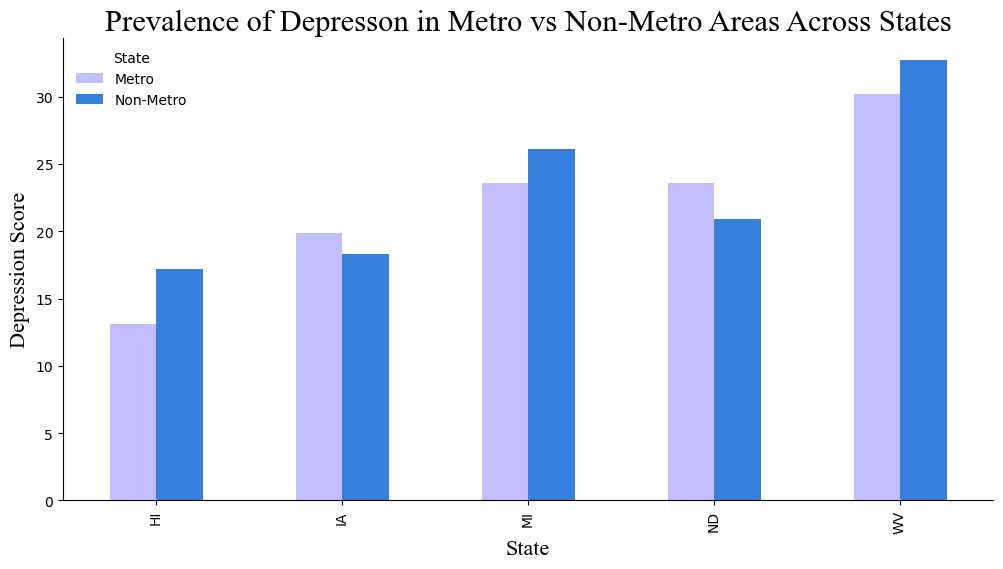

In [162]:
# Grouped Bar Plot
custom_color_4 = ['#c2beffff','#377fddff']
ax = pivot_table_reordered4.plot(kind='bar', figsize=(12,6), color=custom_color_4)
ax.set_title("Prevalence of Depresson in Metro vs Non-Metro Areas Across States", fontsize=22,fontname='Times New Roman')
#ax.set_xlabel("States",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=16,fontname='Times New Roman')
ax.set_xlabel("State",fontsize=16,fontname='Times New Roman')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)

In [163]:
# Save Figure
DepressionPrevalenceByMetroVsNonMetroFig = ax.get_figure()
DepressionPrevalenceByMetroVsNonMetroFig.savefig("figures/DepressionByMetroVsNonMetro_BarGraph.png", bbox_inches = 'tight',transparent=True,dpi=300)

# DEPRESSION BY SERVED VS NON SERVED (ACROSS STATES)
- Among adults who have served vs not served in the military, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder shows the prevalence of depression within each income bracket
- Shows the prevelance of depression in those who have served vs those who have not

In [164]:
df5 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value'])
hasServed = ['Depression - Served','Depression - Not Served'] # Filter
df_clean5 = df5[df5['Measure'].isin(hasServed)] 
newNamelyst5 = [] # make empty list to store new row/entry names when iterating thru measures column
for row in df_clean5['Measure']:
    if (row == 'Depression - Served'): # if row == old/original name
          newNamelyst5.append('Has Served') # add new name to list for the new column
    elif(row == 'Depression - Not Served'):
          newNamelyst5.append('Has Not Served')   
df_clean5['Served vs Not Served'] = newNamelyst5 # adds the new list of desired labels as new column
df_clean5.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/1685979710.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean5['Served vs Not Served'] = newNamelyst5 # adds the new list of desired labels as new column


,Measure,State,Value,Served vs Not Served
160,Depression - Not Served,HI,13.9,Has Not Served
161,Depression - Not Served,IA,19.7,Has Not Served
162,Depression - Not Served,MI,24.9,Has Not Served
163,Depression - Not Served,ND,23.0,Has Not Served
164,Depression - Not Served,WV,32.1,Has Not Served


In [165]:
pivot_df5 = df_clean5.pivot(index = 'State', columns=['Served vs Not Served'] , values = 'Value')
pivot_df5

Served vs Not Served,Has Not Served,Has Served
State,,
HI,13.9,13.2
IA,19.7,14.0
MI,24.9,16.1
ND,23.0,17.1
WV,32.1,23.2


In [166]:
new_column_order5 = ['Has Served','Has Not Served'] 
pivot_table_reordered5 = pivot_df5.reindex(columns=new_column_order5)
transposed_pivot5 = pivot_table_reordered5.T # switches axis 
transposed_pivot5

State,HI,IA,MI,ND,WV
Served vs Not Served,,,,,
Has Served,13.2,14.0,16.1,17.1,23.2
Has Not Served,13.9,19.7,24.9,23.0,32.1


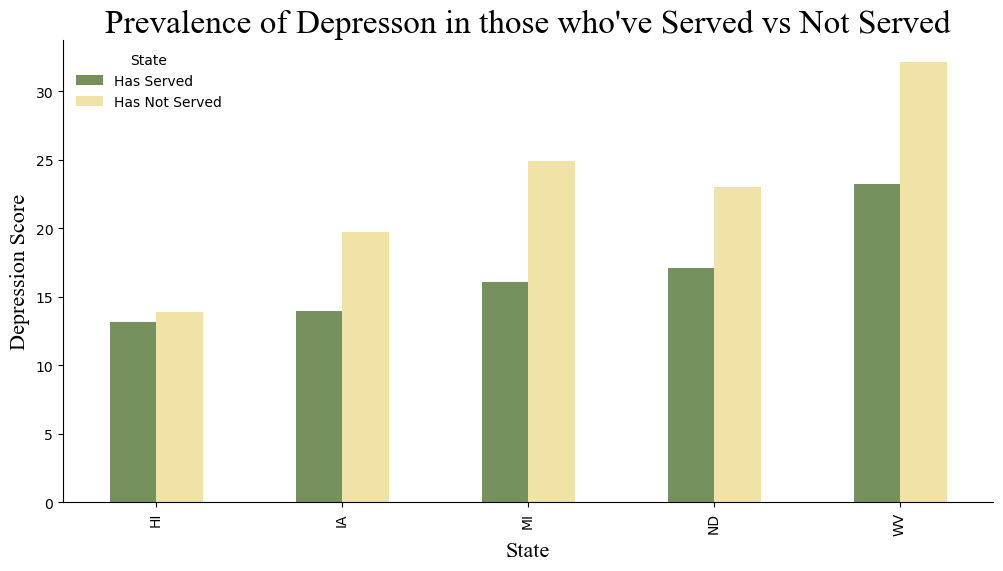

In [168]:
# Grouped Bar Plot
custom_color_5 = ['#76915eff','#f1e2a7ff'] 
ax = pivot_table_reordered5.plot(kind='bar', figsize=(12,6), color=custom_color_5)
ax.set_title("Prevalence of Depresson in those who've Served vs Not Served",fontsize=24,fontname="Times New Roman")
#ax.set_xlabel("States",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=16,fontname="Times New Roman")
ax.set_xlabel("State",fontsize=16,fontname="Times New Roman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)

In [170]:
# Save Figure
DepressionPrevalenceByServedVsNotServedFig = ax.get_figure()
DepressionPrevalenceByServedVsNotServedFig.savefig("figures/DepressionByServedVsNotServed_BarGraph.png", bbox_inches = 'tight',transparent=True,dpi=300)

# DEPRESSION ACROSS POPULATIONS WITH VARIOUS DIFFICULTIES (ACROSS STATES)
- Among adults with various difficulties, the following visualization shows the percentage that reported to have been told at somepoint by a health professional that they had a depressive disorder
- Shows the prevalence of depression in those with various difficulties vs those without a disibility

In [171]:
df6 = pd.read_csv("Df_5states_DepressionALL_FACTORS.csv", usecols=['Measure','State','Value']) # read in csv
disability = ['Depression - Difficulty Hearing', # make filter for the income labels in the Measure column
              'Depression - Difficulty Seeing',
              'Depression - Difficulty With Cognition', 
              'Depression - Difficulty With Mobility', 
              'Depression - Difficulty With Self-Care',
              'Depression - Independent Living Difficulty',
              'Depression - Without a Disability']
df_clean6 = df6[df6['Measure'].isin(disability)] # only get entries w/ income in measure
newNamelyst6 = [] # make empty list to store new row/entry names when iterating thru measures column
for row in df_clean6['Measure']:
    if (row == 'Depression - Difficulty Hearing'):
          newNamelyst6.append('Hearing Disability')
    elif(row == 'Depression - Difficulty Seeing'):
          newNamelyst6.append('Vision Disabiltiy')
    elif(row == 'Depression - Difficulty With Cognition'):
        newNamelyst6.append('Cognitive Disability')
    elif(row == 'Depression - Difficulty With Mobility'):
        newNamelyst6.append('Mobility Disabiltiy')
    elif(row == 'Depression - Difficulty With Self-Care'):
        newNamelyst6.append('Self-Care Difficulty')
    elif(row == 'Depression - Independent Living Difficulty'):
         newNamelyst6.append('Independent Living Difficulty')
    elif(row == 'Depression - Without a Disability'):
        newNamelyst6.append('No Disability')
df_clean6['Has Disabiltiy/Difficulty vs Does Not'] = newNamelyst6
df_clean6.head()

/var/folders/89/1xx8slwx0sz7bb2jd1vmzghh0000gn/T/ipykernel_29758/3973135722.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean6['Has Disabiltiy/Difficulty vs Does Not'] = newNamelyst6


,Measure,State,Value,Has Disabiltiy/Difficulty vs Does Not
105,Depression - Difficulty Hearing,HI,19.0,Hearing Disability
106,Depression - Difficulty Hearing,IA,23.5,Hearing Disability
107,Depression - Difficulty Hearing,MI,26.8,Hearing Disability
108,Depression - Difficulty Hearing,ND,26.8,Hearing Disability
109,Depression - Difficulty Hearing,WV,42.4,Hearing Disability


In [172]:
pivot_df6 = df_clean6.pivot(index = 'State', columns=['Has Disabiltiy/Difficulty vs Does Not'] , values = 'Value')
pivot_df6

Has Disabiltiy/Difficulty vs Does Not,Cognitive Disability,Hearing Disability,Independent Living Difficulty,Mobility Disabiltiy,No Disability,Self-Care Difficulty,Vision Disabiltiy
State,,,,,,,
HI,45.9,19.0,41.5,24.5,9.0,39.5,29.3
IA,54.2,23.5,52.4,32.8,13.0,46.6,37.5
MI,62.8,26.8,55.9,39.0,16.3,45.7,36.6
ND,64.6,26.8,65.5,39.4,15.3,53.8,41.0
WV,65.2,42.4,56.9,45.7,20.3,56.6,47.6


In [173]:
new_column_order6 = ['Hearing Disability','Vision Disabiltiy','Cognitive Disability', 'Mobility Disabiltiy','Self-Care Difficulty','Independent Living Difficulty', 'No Disability'] 
pivot_table_reordered6 = pivot_df6.reindex(columns=new_column_order6) # Reorder the columns
transposed_pivot6 = pivot_table_reordered6.T # switches axis 
transposed_pivot6

State,HI,IA,MI,ND,WV
Has Disabiltiy/Difficulty vs Does Not,,,,,
Hearing Disability,19.0,23.5,26.8,26.8,42.4
Vision Disabiltiy,29.3,37.5,36.6,41.0,47.6
Cognitive Disability,45.9,54.2,62.8,64.6,65.2
Mobility Disabiltiy,24.5,32.8,39.0,39.4,45.7
Self-Care Difficulty,39.5,46.6,45.7,53.8,56.6
Independent Living Difficulty,41.5,52.4,55.9,65.5,56.9
No Disability,9.0,13.0,16.3,15.3,20.3


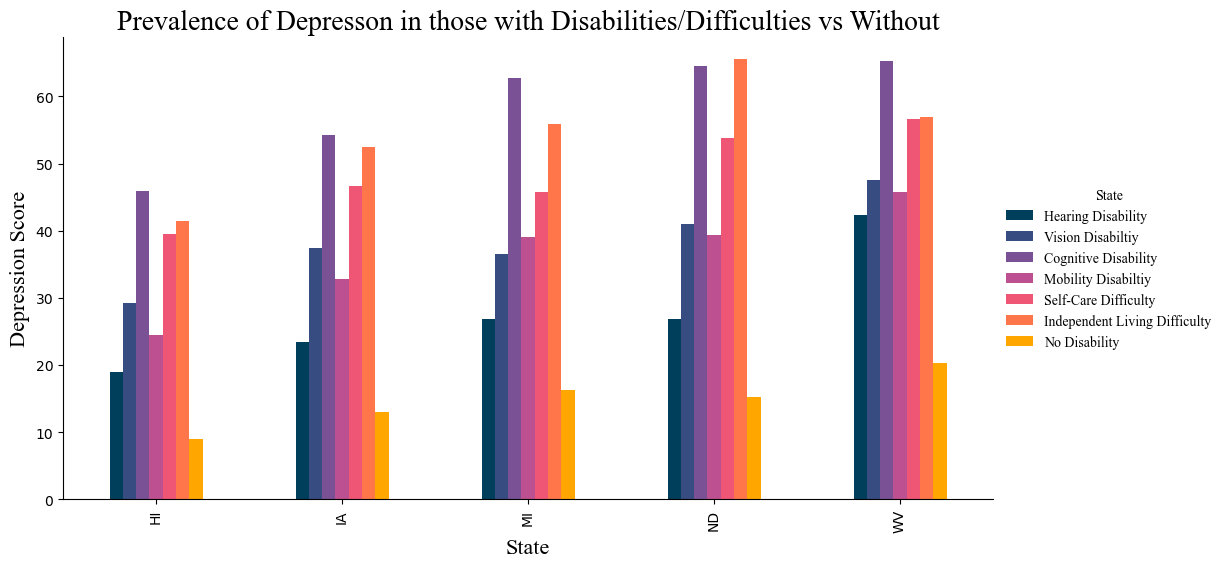

In [196]:
# Grouped Bar Plot
custom_color_6 = ['#003f5c', '#374c80', '#7a5195', '#bc5090','#ef5675', '#ff764a', '#ffa600']
ax = pivot_table_reordered6.plot(kind='bar', figsize=(12,6), color=custom_color_6)
ax.set_title("Prevalence of Depresson in those with Disabilities/Difficulties vs Without", fontsize=20,fontname="Times New Roman")
#ax.set_xlabel("States",fontsize=14)
ax.set_ylabel("Depression Score",fontsize=16,fontname="Times New Roman")
ax.set_xlabel("State",fontsize=16,fontname="Times New Roman")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='State',frameon=False,fontsize=12,
          prop={'family': 'Times New Roman'},
          title_fontproperties={'family':'Times New Roman'},
         loc='center left',bbox_to_anchor=(1,0.5)
         )
# add value labels on each bar 

# for container in ax.containers:
  #   ax.bar_label(container,fmt='%.1f',label_type='edge',fontsize=14,fontfamily='Times New Roman',rotation=90)
   

In [198]:
# Save Figure
DepressionPrevalenceByDisabilityFig = ax.get_figure()
DepressionPrevalenceByDisabilityFig.savefig("figures/DepressionByDisability_BarGraph.png", bbox_inches = 'tight',transparent=True,dpi=300)